In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    log_loss,
    precision_recall_fscore_support,
    roc_auc_score,
)


In [3]:
# Reading in the data
df = pd.read_parquet("../data/processed/btc.parquet",engine = 'pyarrow')

In [11]:
df.head()

,received_at,exchange,symbol,depth,data,orderbook_bids,orderbook_asks,VWPA,OBI,best_bid,best_ask,mid_price,best_ask_lag1,best_ask_lag7,best_ask_lag14,best_bid_lag1,best_bid_lag7,best_bid_lag14,mid_price_lag1,direction
0,2026-02-25 04:23:52.616772+00:00,binance,BTCUSDT,20,"{'E': 1771993432410, 'T': 1771993432408, 'U': ...","[[5000.0, 41.989], [6555.8, 0.03], [15061.0, 0...","[[65557.3, 3.543], [65565.9, 0.0], [65567.8, 0...","[23024.86176268541, 65825.6443031704]",0.681941,5000.0,65557.3,35278.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
1,2026-02-25 04:23:52.718327+00:00,binance,BTCUSDT,20,"{'E': 1771993432512, 'T': 1771993432510, 'U': ...","[[1000.0, 37.131], [5000.0, 42.009], [6555.8, ...","[[65557.3, 3.594], [65563.1, 0.169], [65563.8,...","[22371.45248817456, 65710.90865529644]",0.746986,1000.0,65557.3,33278.65,65557.3,NaN,NaN,5000.0,NaN,NaN,35278.65,DOWN
2,2026-02-25 04:23:52.838144+00:00,binance,BTCUSDT,20,"{'E': 1771993432614, 'T': 1771993432612, 'U': ...","[[1000.0, 37.131], [5000.0, 42.009], [6555.8, ...","[[65557.3, 3.523], [65563.5, 0.083], [65582.7,...","[23876.96591794257, 65715.02192314663]",0.839938,1000.0,65557.3,33278.65,65557.3,NaN,NaN,1000.0,NaN,NaN,33278.65,DOWN
3,2026-02-25 04:23:52.922980+00:00,binance,BTCUSDT,20,"{'E': 1771993432716, 'T': 1771993432712, 'U': ...","[[5000.0, 42.009], [6555.8, 0.0], [15061.0, 0....","[[65557.3, 3.527], [65563.8, 0.071], [65564.1,...","[21415.06728257552, 65629.71101179835]",0.842719,5000.0,65557.3,35278.65,65557.3,NaN,NaN,1000.0,NaN,NaN,33278.65,UP
4,2026-02-25 04:23:53.024983+00:00,binance,BTCUSDT,20,"{'E': 1771993432818, 'T': 1771993432816, 'U': ...","[[1000.0, 37.131], [5000.0, 42.009], [6555.8, ...","[[65557.3, 3.525], [65589.8, 0.004], [65590.0,...","[9133.876211105686, 67695.11074865324]",0.443399,1000.0,65557.3,33278.65,65557.3,NaN,NaN,5000.0,NaN,NaN,35278.65,DOWN


In [5]:
# Lagging the mid price (we will use this response)
# So that we can convert the response to a categorical variable
df['mid_price_lag1'] = df["mid_price"].shift(1)

# Direction of price 
# (response to use for logistic)
# 
df['direction'] = np.where(
    df["mid_price_lag1"].isna(),
    np.nan,
    np.where(df["mid_price"] - df["mid_price_lag1"] > 0, "UP", "DOWN")
)

Fitting Base line model

Notes
- Ensure that determining initial baseline parameters (and the later hyperparameter tuning) is done within the CV
- 

In [13]:
# First need to make response a categorical variable
# In this case we will determine the direction of the price movement (Up and Down) to represent whether the
# next day's price will mvoe up or down


# -------------------------
# 1) Define features/target
# -------------------------
feature_cols = [
    "best_bid_lag1",
    "best_bid_lag7",
    "best_bid_lag14",
    "best_ask_lag1",
    "best_ask_lag7",
    "best_ask_lag14",
    "OBI",
    "VWPA",
    "mid_price_lag1",
    # add more engineered features here
]

# Example target mapping: UP=1, DOWN=0
y = (df["direction"] == "UP").astype(int)
X = X = df[feature_cols].apply(pd.to_numeric, errors="coerce")


# Optional: drop rows with missing target
mask = y.notna()
X, y = X[mask], y[mask]

# -------------------------
# 2) Rolling train/test setup
# -------------------------
train_window = 1000
test_horizon = 200
step = test_horizon  # move forward by 200 each iteration
gap = 0              # set >0 if your label uses a forward horizon

def rolling_splits(n_samples, train_window, test_horizon, step, gap=0):
    start = 100
    while True:
        train_start = start
        train_end = train_start + train_window
        test_start = train_end + gap
        test_end = test_start + test_horizon
        if test_end > n_samples:
            break
        yield train_start, train_end, test_start, test_end
        start += step

# -------------------------
# 3) Choose penalty setup
# -------------------------
# penalty options: "l1", "l2", "elasticnet", None
penalty = "l2"         # change to "l1" when you decide
C = 1.0                # inverse regularization strength (smaller => stronger penalty)
l1_ratio = None        # set between 0 and 1 only if penalty="elasticnet"

# Solver compatibility:
# - l1 -> solver="saga" (or "liblinear" for smaller problems)
# - l2 -> "lbfgs" / "saga" / others
# - elasticnet -> "saga" only
if penalty == "l1":
    solver = "saga"
elif penalty == "elasticnet":
    solver = "saga"
    l1_ratio = 0.5  # example
elif penalty == "l2":
    solver = "lbfgs"
else:
    solver = "lbfgs"  # for penalty=None

# -------------------------
# 4) Build model pipeline
# -------------------------
base_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty=penalty,
        C=C,
        solver=solver,
        l1_ratio=l1_ratio,
        max_iter=2000,
        random_state=42
    ))
])

# -------------------------
# 5) Rolling fit + evaluate
# -------------------------
metrics_rows = []
pred_dfs = []

n_samples = len(X)
for split_id, (tr_s, tr_e, te_s, te_e) in enumerate(
    rolling_splits(n_samples, train_window, test_horizon, step, gap=gap)
):
    X_train = X.iloc[tr_s:tr_e]
    y_train = y.iloc[tr_s:tr_e]
    X_test = X.iloc[te_s:te_e]
    y_test = y.iloc[te_s:te_e]

    status = "ok"
    if pd.Series(y_train).nunique() < 2:
        status = "skip_single_class_train"

    if status == "ok":
        clf = clone(base_clf)
        clf.fit(X_train, y_train)

        y_prob = clf.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if pd.Series(y_test).nunique() == 2 else np.nan
        ll = log_loss(y_test, y_prob, labels=[0, 1])
        brier = brier_score_loss(y_test, y_prob)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="binary", zero_division=0
        )

        pred_df = pd.DataFrame(
            {
                "split_id": split_id,
                "y_true": y_test.to_numpy(),
                "y_prob": y_prob,
                "y_pred": y_pred,
            },
            index=y_test.index,
        )
        pred_dfs.append(pred_df)
    else:
        acc = auc = ll = brier = prec = rec = f1 = np.nan

    metrics_rows.append(
        {
            "split_id": split_id,
            "status": status,
            "train_start": tr_s,
            "train_end": tr_e,
            "test_start": te_s,
            "test_end": te_e,
            "train_pos_rate": float(np.mean(y_train)) if len(y_train) else np.nan,
            "test_pos_rate": float(np.mean(y_test)) if len(y_test) else np.nan,
            "accuracy": acc,
            "roc_auc": auc,
            "log_loss": ll,
            "brier": brier,
            "precision": prec,
            "recall": rec,
            "f1": f1,
        }
    )

metrics_df = pd.DataFrame(metrics_rows)
preds_df = pd.concat(pred_dfs).sort_index() if pred_dfs else pd.DataFrame()

display(metrics_df.head())
print("Splits:", len(metrics_df), "| ok:", int((metrics_df["status"] == "ok").sum()))
print("Mean ROC AUC (ok splits):", metrics_df.loc[metrics_df["status"] == "ok", "roc_auc"].mean())
print("Mean LogLoss (ok splits):", metrics_df.loc[metrics_df["status"] == "ok", "log_loss"].mean())

# Optional: overall metrics on all concatenated out-of-sample predictions
if not preds_df.empty:
    overall_acc = accuracy_score(preds_df["y_true"], preds_df["y_pred"])
    overall_auc = roc_auc_score(preds_df["y_true"], preds_df["y_prob"]) if preds_df["y_true"].nunique() == 2 else np.nan
    overall_ll = log_loss(preds_df["y_true"], preds_df["y_prob"], labels=[0, 1])
    print("Overall OOS accuracy:", overall_acc)
    print("Overall OOS ROC AUC:", overall_auc)
    print("Overall OOS LogLoss:", overall_ll)

# Example: look at the last split's confusion matrix
if not preds_df.empty:
    last_split = preds_df["split_id"].max()
    last = preds_df[preds_df["split_id"] == last_split]
    print("Last split confusion matrix:\n", confusion_matrix(last["y_true"], last["y_pred"]))


c:\Users\Spike\anaconda3\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['VWPA']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Spike\anaconda3\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['VWPA']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Spike\anaconda3\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['VWPA']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Spike\anaconda3\Lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['VWPA']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\Spike\anaconda3\Lib\site-packages\s

,split_id,status,train_start,train_end,test_start,test_end,train_pos_rate,test_pos_rate,accuracy,roc_auc,log_loss,brier,precision,recall,f1
0,0,ok,100,1100,1100,1300,0.409,0.435,0.825,0.922694,0.355988,0.114624,0.728070,0.954023,0.825871
1,1,ok,300,1300,1300,1500,0.417,0.410,0.775,0.898305,0.373216,0.126409,0.660870,0.926829,0.771574
2,2,ok,500,1500,1500,1700,0.419,0.450,0.825,0.913838,0.322263,0.110503,0.743363,0.933333,0.827586
3,3,ok,700,1700,1700,1900,0.428,0.425,0.790,0.896471,0.366820,0.119174,0.772152,0.717647,0.743902
4,4,ok,900,1900,1900,2100,0.433,0.425,0.785,0.888286,0.365684,0.126030,0.694444,0.882353,0.777202


Splits: 408 | ok: 408
Mean ROC AUC (ok splits): 0.8198329490755857
Mean LogLoss (ok splits): 0.42179527652937204
Overall OOS accuracy: 0.7929044117647058
Overall OOS ROC AUC: 0.8729551816698513
Overall OOS LogLoss: 0.4217952765293721
Last split confusion matrix:
 [[85 19]
 [ 7 89]]


In [18]:
# Further examining the metrics_df to better understand the applicability of this model in this dataset
# Quick simply EDA of statistical metrics
print("Average accuracy across splits:")
print(metrics_df["accuracy"].mean()),print(" ")
print("Average Test postiive rate:")
print(metrics_df["test_pos_rate"].mean()),print(" ")
print("Average Train Positive Rate:")
print(metrics_df["train_pos_rate"].mean()),print(" ")

Average accuracy across splits:
0.7929044117647058
 
Average Test postiive rate:
0.3813725490196079
 
Average Train Positive Rate:
0.38104411764705887
 


(None, None)

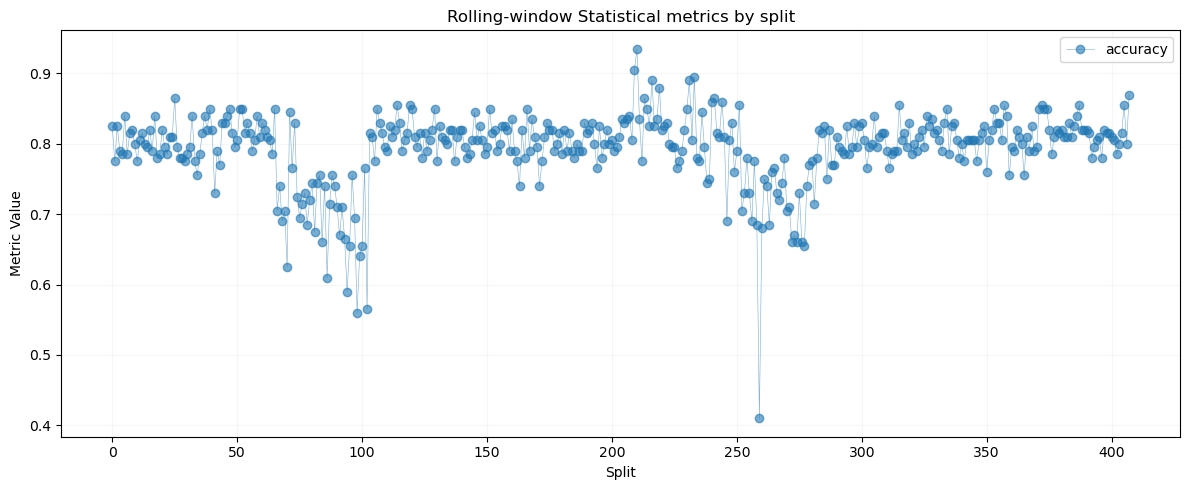

In [23]:
# For quick visualisation
# To observe if there is a range of splits where the model is not as robust
# 

# Input cols here, adjust alpha if there is too much information
cols = ["accuracy"]
x = metrics_df["split_id"]

plt.figure(figsize=(12,5))
for c in cols:
    if c in metrics_df.columns:
        plt.plot(x,metrics_df[c],marker = "o", linewidth =0.4,label=c,alpha=0.6)

plt.xlabel("Split")
plt.ylabel("Metric Value")
plt.title("Rolling-window Statistical metrics by split")
plt.grid(True,alpha=0.1)
plt.legend()
plt.tight_layout()
plt.show()

Hypertuning of model parameters. 


Potentially include some penalty term as well to prevent overfitting?
